# Transformer 구조와 핵심 구성 요소

- 변환기
    - 입력된 토큰 표현을 문맥이 반영된 표현으로 계속 변환하는 역할의 모델
    - 토큰 ID -> 단순 임베딩 벡터 -> 문맥이 반영된 토큰 벡터
        -> 번역/분류/다음 토큰 예측 결과
## 정의

**Transformer**는 RNN의 순환 계산 대신 Attention을 중심으로 시퀀스를 처리하는 신경망 구조이다. 원형 Transformer는 입력을 이해하는 **Encoder**와 출력을 생성하는 **Decoder**로 구성된다.

Encoder는 입력 문장의 모든 위치를 서로 참고하여 문맥 표현인 `memory`를 만든다. Decoder는 지금까지 공개된 출력 토큰과 Encoder의 `memory`를 함께 참고하여 다음 토큰의 점수인 `logits`를 만든다.

## 필요한 이유와 사용처

RNN은 토큰을 시간 순서대로 처리하므로 긴 시퀀스에서 계산을 병렬화하기 어렵다. Transformer는 한 층 안의 여러 토큰 관계를 동시에 계산하고, Multi-Head Attention으로 서로 다른 관계를 함께 학습할 수 있다.

기계 번역과 요약처럼 입력을 받아 새 문장을 만드는 작업에 원형 Encoder–Decoder Transformer를 사용한다. 이후 BERT는 Encoder를 중심으로, GPT는 Causal Attention을 사용하는 Decoder 계열을 중심으로 발전했다.


 ## 01. Transformer 전체 구조를 먼저 보기

Transformer는 여러 부품을 한꺼번에 외우는 것이 아니라 **입력 문장을 처리하는 왼쪽 Encoder**와 **출력 문장을 만드는 오른쪽 Decoder**로 먼저 나누어 읽는다.

아래 첫 그림은 현재 코드의 데이터 흐름을 단순화한 것이다. source ID는 Embedding과 위치 정보를 거쳐 Encoder `memory`가 되고, Decoder는 shift된 target 입력과 `memory`를 결합해 target 어휘의 logits를 만든다.

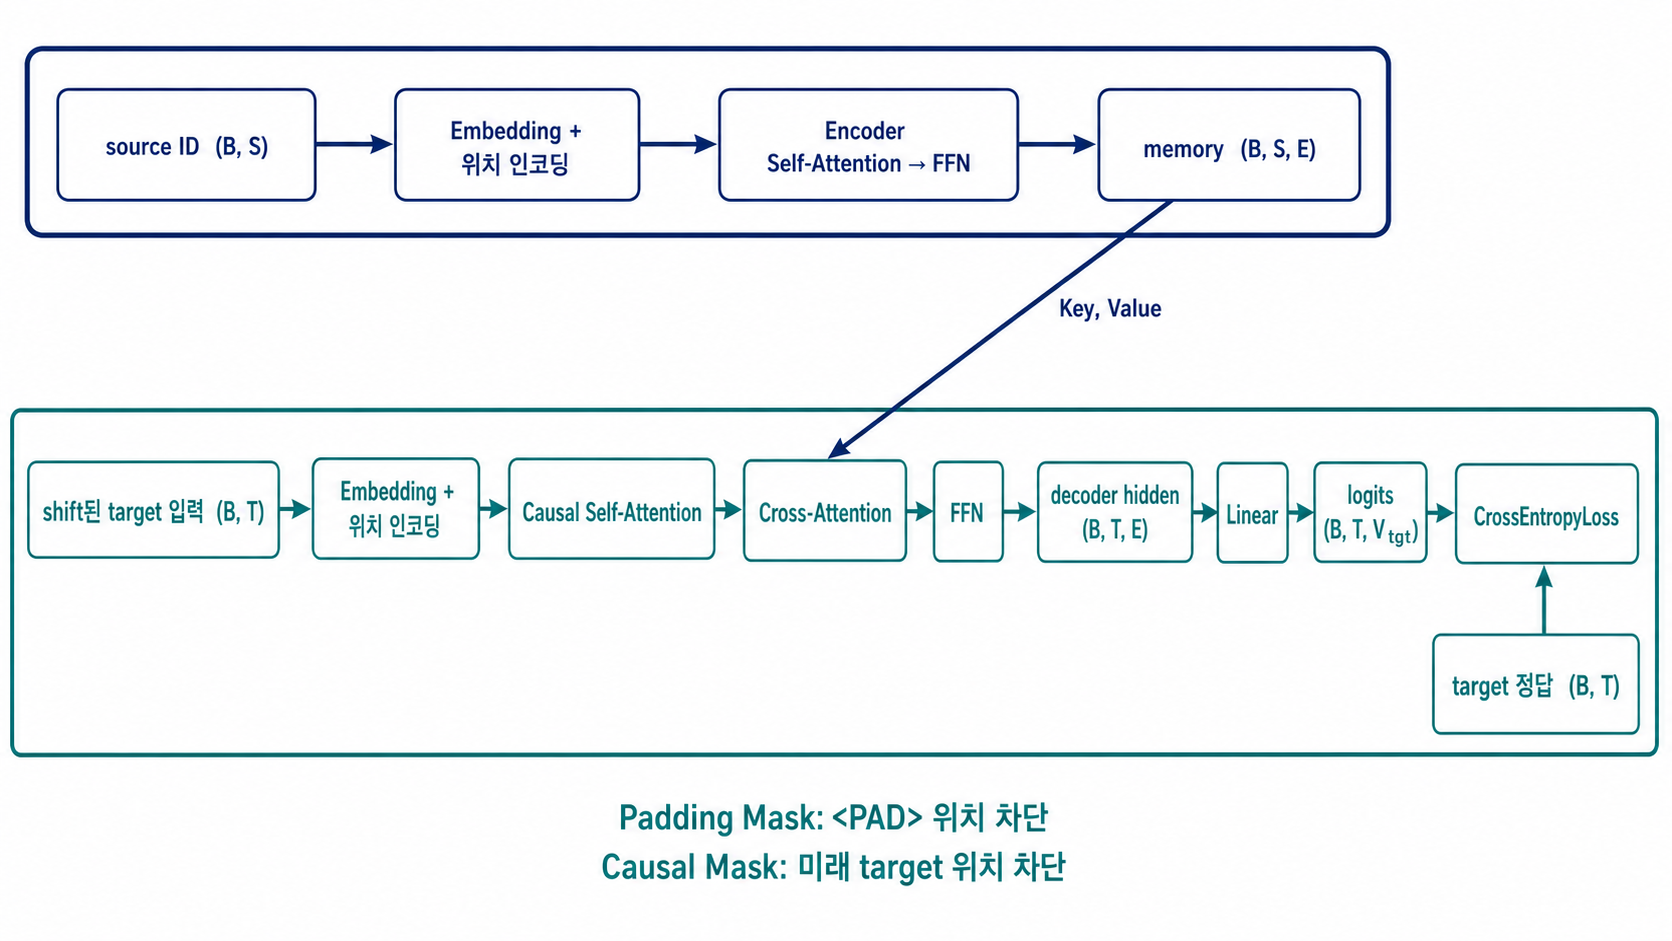

다음 그림은 원본 교안에서 사용한 Transformer 구조이다. 아래에서 위로 읽으면 된다.

1. 왼쪽 아래의 입력 토큰이 `Input Embedding + Positional Encoding`을 거친다.
2. 왼쪽 Encoder 층은 `Multi-Head Self-Attention → Add & Norm → Feed Forward → Add & Norm`을 수행한다.
3. 오른쪽 Decoder는 `Masked Multi-Head Attention`으로 미래 토큰을 가린다.
4. 그 위의 Multi-Head Attention은 Decoder 표현을 Query, Encoder 출력을 Key·Value로 사용하는 Cross-Attention이다.
5. 가장 위의 Linear가 Decoder 벡터를 어휘별 logits로 바꾸고 softmax가 다음 토큰 확률을 만든다.

그림의 `N×`는 같은 형태의 층을 여러 번 쌓는다는 뜻이다. 현재 수업 코드는 전체 연결을 빠르게 확인하기 위해 Encoder와 Decoder를 각각 한 층만 사용한다.

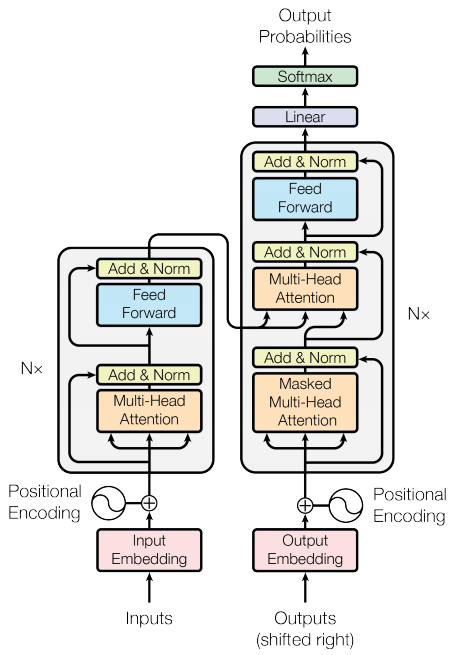

이미지 출처: [TensorFlow Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer)


## 02. Encoder와 Decoder가 하는 일

Encoder는 source 전체를 한 번에 읽고 source 각 위치마다 문맥이 반영된 벡터를 만든다. 이 출력이 `memory (B, S, E)`이다. `B`는 문장 수, `S`는 source 토큰 수, `E`는 토큰 벡터 차원이다.

Decoder는 지금까지 알고 있는 target 토큰을 입력으로 받는다. Decoder의 각 위치는 미래 target을 보지 못한 상태에서 Encoder `memory`를 참고하고, 다음 토큰 후보 점수를 만든다.

Transformer 내부의 Attention은 입력 원천에 따라 구분한다.

- **Encoder Self-Attention**: source가 Q·K·V를 모두 제공하여 source 내부 관계를 계산한다.
- **Decoder Causal Self-Attention**: target이 Q·K·V를 제공하지만 미래 target 위치는 가린다.
- **Cross-Attention**: Decoder의 target 표현이 Q이고 Encoder `memory`가 K·V이다.

```text
source ID (B, S)
→ Encoder
→ memory (B, S, E)

shift된 target ID (B, T) + memory (B, S, E)
→ Decoder
→ decoder hidden (B, T, E)
→ Linear
→ logits (B, T, V_tgt)
```

`V_tgt`는 target 어휘에 등록된 토큰 수이다. 따라서 logits의 마지막 축에는 다음 위치에 올 수 있는 모든 target 토큰 후보 점수가 놓인다.


## 03. Positional Encoding: 토큰 순서를 알려 주는 값

Self-Attention은 토큰 사이의 관계를 계산하지만, 입력 순서를 따라 한 칸씩 이동하는 구조가 아니다. 그래서 토큰 임베딩만 전달하면 같은 토큰 집합의 순서를 구분하기 어렵다.

**Positional Encoding**은 위치마다 다른 벡터를 만들어 토큰 임베딩에 더하는 방법이다. 연결하는 것이 아니라 더하기 때문에 `(B, T, E)` shape는 그대로 유지된다.

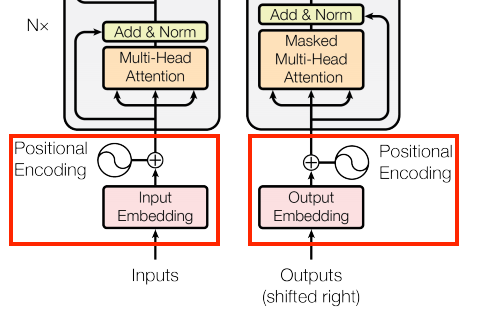

이미지 출처: [TensorFlow Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer)

원 논문은 짝수 채널에 sin, 홀수 채널에 cos 값을 사용한다.

$$
PE_{(pos,2i)}=\sin\left(\frac{pos}{10000^{2i/E}}\right),
\qquad
PE_{(pos,2i+1)}=\cos\left(\frac{pos}{10000^{2i/E}}\right)
$$

- `pos`: 문장 안의 토큰 위치
- `i`: 벡터 안의 채널 번호
- `E`: 임베딩 차원

이어지는 코드는 0 벡터에 위치값만 더한다. 입력 토큰 정보가 없는 상태에서도 0번 위치와 1번 위치의 출력이 달라지면 위치 정보가 실제로 추가된 것이다.


In [1]:
import math

import torch
import torch.nn as nn

torch.manual_seed(42)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=32):
        super().__init__()

        # 토큰 위치와 채널별 sin·cos 주기를 만든다.
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        positional_values = torch.zeros(max_len, d_model)
        positional_values[:, 0::2] = torch.sin(position * div_term)
        positional_values[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("positional_values", positional_values.unsqueeze(0))

    def forward(self, embeddings):
        sequence_length = embeddings.size(1)
        return embeddings + self.positional_values[:, :sequence_length]


position_encoder = PositionalEncoding(d_model=8, max_len=4)
zero_embeddings = torch.zeros(1, 4, 8)
positioned = position_encoder(zero_embeddings)

print("입력 / 출력 shape:", tuple(zero_embeddings.shape), tuple(positioned.shape))
print("위치 0:", positioned[0, 0, :6])
print("위치 1:", positioned[0, 1, :6])
print("위치 0과 1이 같은가:", torch.allclose(positioned[0, 0], positioned[0, 1]))


입력 / 출력 shape: (1, 4, 8) (1, 4, 8)
위치 0: tensor([0., 1., 0., 1., 0., 1.])
위치 1: tensor([0.8415, 0.5403, 0.0998, 0.9950, 0.0100, 0.9999])
위치 0과 1이 같은가: False


## 04. Attention 뒤의 FFN, Residual Connection과 LayerNorm

Attention이 문장 안의 **여러 토큰 정보를 섞는 역할**이라면, Position-wise FFN은 섞인 결과를 **토큰 위치별로 변환하는 역할**이다. 모든 위치가 같은 두 Linear 계층을 사용하지만 각 위치의 벡터는 독립적으로 처리된다.

```text
토큰 벡터 E차원
→ Linear(E → d_ff)
→ 활성화 함수
→ Linear(d_ff → E)
→ 다시 E차원
```

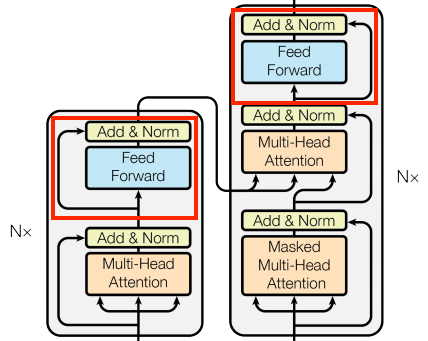

**Residual Connection**은 하위층의 입력 `x`를 출력에 다시 더하는 연결이다. Attention이나 FFN이 정보를 크게 바꾸더라도 원래 입력이 다음 단계로 전달되는 경로를 남긴다.

**LayerNorm**은 각 토큰 벡터의 특성값을 정규화하여 여러 층을 지나는 동안 학습을 안정시키는 계층이다. 원본 그림의 `Add & Norm`은 다음 흐름을 묶어 표현한다.

```text
x
├──────────────┐
└→ 하위층(x) ──┴→ x + 하위층(x) → LayerNorm
```

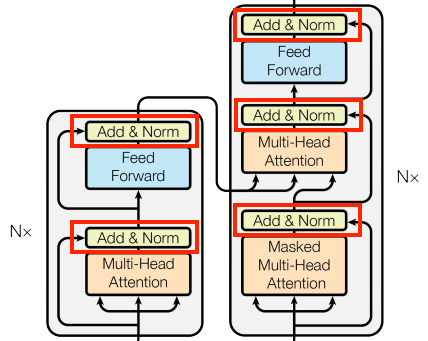

이미지 출처: [TensorFlow Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer)

이어지는 PyTorch `TransformerEncoderLayer`와 `TransformerDecoderLayer`에는 Multi-Head Attention, FFN, Residual Connection과 LayerNorm이 이미 포함되어 있다. 따라서 수업 코드에서 이 부품들을 다시 수동 구현하지 않는다.


## 05. target shift와 두 종류의 mask

학습할 때 Decoder에는 정답 문장을 그대로 넣지 않고 한 칸 오른쪽으로 민 입력을 사용한다. 현재까지의 정답 토큰으로 **다음 토큰**을 맞히게 만들기 위해서이다.

```text
전체 target:  <SOS>  가    나    <EOS> <PAD> <PAD>
Decoder 입력: <SOS>  가    나    <EOS> <PAD>
손실 정답:    가     나    <EOS> <PAD> <PAD>
```

두 mask는 가리는 이유가 다르다.

- **Padding mask**: 실제 내용이 아닌 `<PAD>` 위치를 Attention의 Key에서 제외한다.
- **Causal mask**: target의 현재 위치가 아직 공개되지 않은 미래 target을 보지 못하게 한다.

PyTorch Transformer의 boolean mask에서는 `True`가 차단할 위치이다. Causal mask는 대각선 위쪽이 `True`인 삼각행렬이며, 첫 target 위치는 자기 자신만 보고 두 번째 위치는 앞의 두 위치까지만 볼 수 있다.


In [2]:
src_token_to_id = {"<PAD>": 0, "A": 1, "B": 2, "C": 3}
tgt_token_to_id = {
    "<PAD>": 0,
    "<SOS>": 1,
    "<EOS>": 2,
    "가": 3,
    "나": 4,
    "다": 5,
}
src_id_to_token = {index: token for token, index in src_token_to_id.items()}
tgt_id_to_token = {index: token for token, index in tgt_token_to_id.items()}

PAD_ID = tgt_token_to_id["<PAD>"]

src_ids = torch.tensor(
    [
        [1, 2, 0],
        [2, 3, 0],
        [1, 3, 0],
        [3, 2, 1],
    ],
    dtype=torch.long,
)
tgt_full = torch.tensor(
    [
        [1, 3, 4, 2, 0, 0],
        [1, 4, 5, 2, 0, 0],
        [1, 3, 5, 2, 0, 0],
        [1, 5, 4, 3, 2, 0],
    ],
    dtype=torch.long,
)

# Decoder 입력과 정답은 target_full에서 한 칸 이동한 관계이다.
tgt_input_ids = tgt_full[:, :-1]
tgt_target_ids = tgt_full[:, 1:]

src_padding_mask = src_ids.eq(src_token_to_id["<PAD>"])
tgt_padding_mask = tgt_input_ids.eq(PAD_ID)
target_length = tgt_input_ids.size(1)
causal_mask = torch.triu(
    torch.ones(target_length, target_length, dtype=torch.bool),
    diagonal=1,
)


def decode_ids(ids, id_to_token):
    return [id_to_token[int(token_id)] for token_id in ids]


print("첫 source:", decode_ids(src_ids[0], src_id_to_token))
print("첫 Decoder 입력:", decode_ids(tgt_input_ids[0], tgt_id_to_token))
print("첫 손실 정답:", decode_ids(tgt_target_ids[0], tgt_id_to_token))
print("첫 source Padding mask:", src_padding_mask[0].int().tolist())
print("첫 target Padding mask:", tgt_padding_mask[0].int().tolist())
print("Causal mask(True=차단):")
print(causal_mask.int())


첫 source: ['A', 'B', '<PAD>']
첫 Decoder 입력: ['<SOS>', '가', '나', '<EOS>', '<PAD>']
첫 손실 정답: ['가', '나', '<EOS>', '<PAD>', '<PAD>']
첫 source Padding mask: [0, 0, 1]
첫 target Padding mask: [0, 0, 0, 0, 1]
Causal mask(True=차단):
tensor([[0, 1, 1, 1, 1],
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0]], dtype=torch.int32)


## 06. PyTorch로 최소 Transformer 연결하기

이제 앞에서 본 부품을 PyTorch의 `TransformerEncoderLayer`와 `TransformerDecoderLayer`로 연결한다. 코드는 각 부품을 다시 구현하지 않고 **Embedding과 위치 정보 → Encoder → Decoder → Linear** 흐름만 보여 준다.

현재 모델은 실행 시간을 줄이기 위해 다음 작은 값을 사용한다.

- 임베딩 차원 `E=16`
- Attention head 2개
- Encoder와 Decoder 각각 1층
- FFN 내부 차원 32

```text
source ID (4, 3)
→ source Embedding + 위치
→ memory (4, 3, 16)

target input ID (4, 5)
→ target Embedding + 위치
→ Decoder + memory
→ hidden (4, 5, 16)
→ Linear
→ logits (4, 5, 6)
```

마지막 `6`은 target 어휘 수이다. 각 target 위치마다 `<PAD>`, `<SOS>`, `<EOS>`, `가`, `나`, `다` 여섯 후보의 점수가 만들어진다.


In [3]:
d_model = 16
num_heads = 2
d_ff = 32

src_embedding = nn.Embedding(
    len(src_token_to_id), d_model, padding_idx=src_token_to_id["<PAD>"]
)
tgt_embedding = nn.Embedding(
    len(tgt_token_to_id), d_model, padding_idx=PAD_ID
)
model_position = PositionalEncoding(d_model=d_model, max_len=16)

encoder_layer = nn.TransformerEncoderLayer(
    d_model=d_model,
    nhead=num_heads,
    dim_feedforward=d_ff,
    dropout=0.0,
    batch_first=True,
)
decoder_layer = nn.TransformerDecoderLayer(
    d_model=d_model,
    nhead=num_heads,
    dim_feedforward=d_ff,
    dropout=0.0,
    batch_first=True,
)
# 일반 Tensor shape를 그대로 확인하도록 실험 단계 NestedTensor 변환을 끈다.
transformer_encoder = nn.TransformerEncoder(
    encoder_layer, num_layers=1, enable_nested_tensor=False
)
transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=1)
output_projection = nn.Linear(d_model, len(tgt_token_to_id))

# 모든 부품을 묶어 optimizer가 전체 파라미터를 갱신하게 한다.
model_parts = nn.ModuleList(
    [
        src_embedding,
        tgt_embedding,
        model_position,
        transformer_encoder,
        transformer_decoder,
        output_projection,
    ]
)

print("임베딩 차원:", d_model)
print("Encoder / Decoder 층 수:", 1, 1)


임베딩 차원: 16
Encoder / Decoder 층 수: 1 1


### 준비한 부품에 source와 target 전달하기

`transformer_forward()`는 앞 셀의 부품을 순서대로 연결한 작은 함수이다. 모델의 새로운 구조를 직접 구현하는 것이 아니라, 각 중간 결과의 shape를 확인하기 위해 Encoder와 Decoder를 나누어 호출한다.

- Embedding에 `√d_model`을 곱하면 벡터의 값 크기만 조정되고 shape는 바뀌지 않는다. 원 Transformer가 Embedding과 Positional Encoding의 값 크기를 맞추기 위해 사용한 입력 scaling이다.
- Encoder가 만든 `memory`는 source 위치별 문맥 벡터이며 Decoder의 Cross-Attention이 참고한다.
- 마지막 Linear가 Decoder hidden을 target 어휘 logits로 바꾼다.
- 손실을 계산할 때 `(B, T, V)`를 `(B×T, V)`로 펼치는 이유는 각 토큰 위치를 V개 어휘 중 하나를 맞히는 분류 문제로 보기 때문이다.


In [4]:
def transformer_forward(source_ids, decoder_input_ids):
    source_padding_mask = source_ids.eq(src_token_to_id["<PAD>"])
    decoder_padding_mask = decoder_input_ids.eq(PAD_ID)
    target_length = decoder_input_ids.size(1)
    decoder_causal_mask = torch.triu(
        torch.ones(
            target_length,
            target_length,
            dtype=torch.bool,
            device=decoder_input_ids.device,
        ),
        diagonal=1,
    )

    source_vectors = model_position(
        src_embedding(source_ids) * math.sqrt(d_model)
    )
    target_vectors = model_position(
        tgt_embedding(decoder_input_ids) * math.sqrt(d_model)
    )
    memory = transformer_encoder(
        source_vectors,
        src_key_padding_mask=source_padding_mask,
    )
    decoder_hidden = transformer_decoder(
        target_vectors,
        memory,
        tgt_mask=decoder_causal_mask,
        tgt_key_padding_mask=decoder_padding_mask,
        memory_key_padding_mask=source_padding_mask,
    )
    logits = output_projection(decoder_hidden)
    return logits, memory, decoder_hidden


criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
with torch.no_grad():
    initial_logits, initial_memory, initial_hidden = transformer_forward(
        src_ids, tgt_input_ids
    )

    # 토큰별 어휘 분류가 되도록 `(B, T, V)`와 `(B, T)`를 펼친다.
    initial_loss = criterion(
        initial_logits.reshape(-1, len(tgt_token_to_id)),
        tgt_target_ids.reshape(-1),
    ).item()

print("Encoder memory:", tuple(initial_memory.shape))
print("Decoder hidden:", tuple(initial_hidden.shape))
print("target logits:", tuple(initial_logits.shape))
print(f"학습 전 loss: {initial_loss:.4f}")


Encoder memory: (4, 3, 16)
Decoder hidden: (4, 5, 16)
target logits: (4, 5, 6)
학습 전 loss: 1.7206


## 07. 짧은 학습으로 연결 확인하기

초기화된 Transformer의 logits는 의미 있는 정답이 아니다. 따라서 같은 네 문장을 짧게 반복 학습하여 loss가 감소하고 다음 토큰을 맞히는지 확인한다.

`CrossEntropyLoss`는 `(B, T, V_tgt)` logits를 target 어휘 분류 문제로 해석한다. 정답이 `<PAD>`인 위치는 `ignore_index=PAD_ID`로 손실에서 제외한다.
`CrossEntropyLoss`가 내부에서 확률 계산까지 처리하므로 모델의 마지막 Linear 출력에는 softmax를 미리 적용하지 않는다.

현재 평가는 정답 이전 토큰을 입력으로 제공하는 **Teacher Forcing 상태의 다음 토큰 예측**이다. 학습 문장 네 개를 잘 맞히더라도 새로운 문장에 대한 일반화 성능을 의미하지 않는다.


In [5]:
optimizer = torch.optim.Adam(model_parts.parameters(), lr=0.01)
epochs = 100
loss_history = []

for epoch in range(1, epochs + 1):
    model_parts.train()
    optimizer.zero_grad()
    logits, _, _ = transformer_forward(src_ids, tgt_input_ids)
    loss = criterion(
        logits.reshape(-1, len(tgt_token_to_id)),
        tgt_target_ids.reshape(-1),
    )
    loss.backward()
    nn.utils.clip_grad_norm_(model_parts.parameters(), max_norm=1.0)
    optimizer.step()
    loss_history.append(loss.item())

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:3d} | loss {loss.item():.6f}")

model_parts.eval()
with torch.no_grad():
    trained_logits, _, _ = transformer_forward(src_ids, tgt_input_ids)
    # 마지막 어휘 축에서 가장 큰 점수의 토큰 ID를 고른다.
    predicted_ids = trained_logits.argmax(dim=-1)

# PAD가 아닌 위치만 골라 정확도를 계산한다.
valid_positions = tgt_target_ids.ne(PAD_ID)
teacher_forced_accuracy = (
    predicted_ids[valid_positions] == tgt_target_ids[valid_positions]
).float().mean().item()

print("학습 전보다 loss가 감소했는가:", loss_history[-1] < initial_loss)
print(f"유효 위치 다음 토큰 정확도: {teacher_forced_accuracy:.2%}")
first_valid_length = int(valid_positions[0].sum())
print(
    "첫 문장 정답(유효 위치):",
    decode_ids(tgt_target_ids[0, :first_valid_length], tgt_id_to_token),
)
print(
    "첫 문장 예측(유효 위치):",
    decode_ids(predicted_ids[0, :first_valid_length], tgt_id_to_token),
)


epoch   1 | loss 1.720612
epoch  25 | loss 0.060426
epoch  50 | loss 0.004199
epoch  75 | loss 0.001797
epoch 100 | loss 0.001236
학습 전보다 loss가 감소했는가: True
유효 위치 다음 토큰 정확도: 100.00%
첫 문장 정답(유효 위치): ['가', '나', '<EOS>']
첫 문장 예측(유효 위치): ['가', '나', '<EOS>']


## 08. 학습과 추론에서 Decoder 입력이 달라진다

학습에서는 정답 문장을 알고 있으므로 `<SOS>`와 정답 이전 토큰을 Decoder 입력으로 한 번에 제공한다. Causal mask가 각 위치에서 미래 정답을 가리기 때문에 여러 위치를 병렬로 계산할 수 있다.

추론에서는 정답을 알 수 없다. `<SOS>` 하나로 시작하여 마지막 위치 logits에서 토큰을 하나 선택하고, 그 예측을 다음 Decoder 입력 뒤에 붙인다. `<EOS>`가 나올 때까지 같은 과정을 반복한다.

```text
학습
<SOS> + 정답 이전 토큰 전체
→ Causal mask를 적용해 병렬 계산
→ 모든 위치의 loss 계산

추론
<SOS>
→ 다음 토큰 예측
→ 예측 토큰을 입력 뒤에 추가
→ 다음 토큰 예측 반복
```

Transformer가 학습을 병렬로 수행할 수 있다는 말이 문장 생성까지 한 번에 끝난다는 뜻은 아니다. 일반적인 자동회귀 생성은 추론 시 토큰을 하나씩 만들어야 한다.


## 09. Transformer에서 BERT와 GPT로

원형 Transformer를 이해하면 BERT와 GPT의 차이는 어떤 블록을 중심으로 사용하는지로 정리할 수 있다.

- **원형 Transformer**: Encoder와 Decoder를 모두 사용하며 번역·요약 같은 입력-출력 생성에 적합하다.
- **BERT**: Transformer Encoder를 여러 층 쌓고 양방향 문맥을 학습한다. 문장 분류, 토큰 분류와 질의응답 같은 이해 작업에 주로 사용한다.
- **GPT**: 미래 토큰을 가리는 Causal Attention을 사용하는 Decoder 계열이다. 이전 토큰으로 다음 토큰을 예측하며 텍스트 생성에 적합하다.

```text
BERT: 전체 입력 문맥 → Encoder → 문맥 벡터
GPT: 이전 토큰 문맥 → Causal Decoder → 다음 토큰 확률
```

다음 BERT 개요 교안에서는 WordPiece 입력이 Transformer Encoder를 지나 문맥 벡터가 되는 과정과 MLM 사전학습을 확인한다.


## 10. 전체 정리

Transformer의 핵심은 Attention 하나만이 아니라 여러 구성 요소의 역할을 연결하는 데 있다.

1. Embedding이 토큰 ID를 벡터로 바꾼다.
2. Positional Encoding이 토큰 순서를 더한다.
3. Encoder Self-Attention이 source 내부 문맥을 반영하여 `memory`를 만든다.
4. Decoder는 Causal Self-Attention으로 미래를 가리고 Cross-Attention으로 `memory`를 참고한다.
5. FFN이 토큰별 표현을 변환하고 Residual Connection과 LayerNorm이 각 하위층의 학습을 안정시킨다.
6. 마지막 Linear가 Decoder hidden을 target 어휘 logits로 바꾼다.

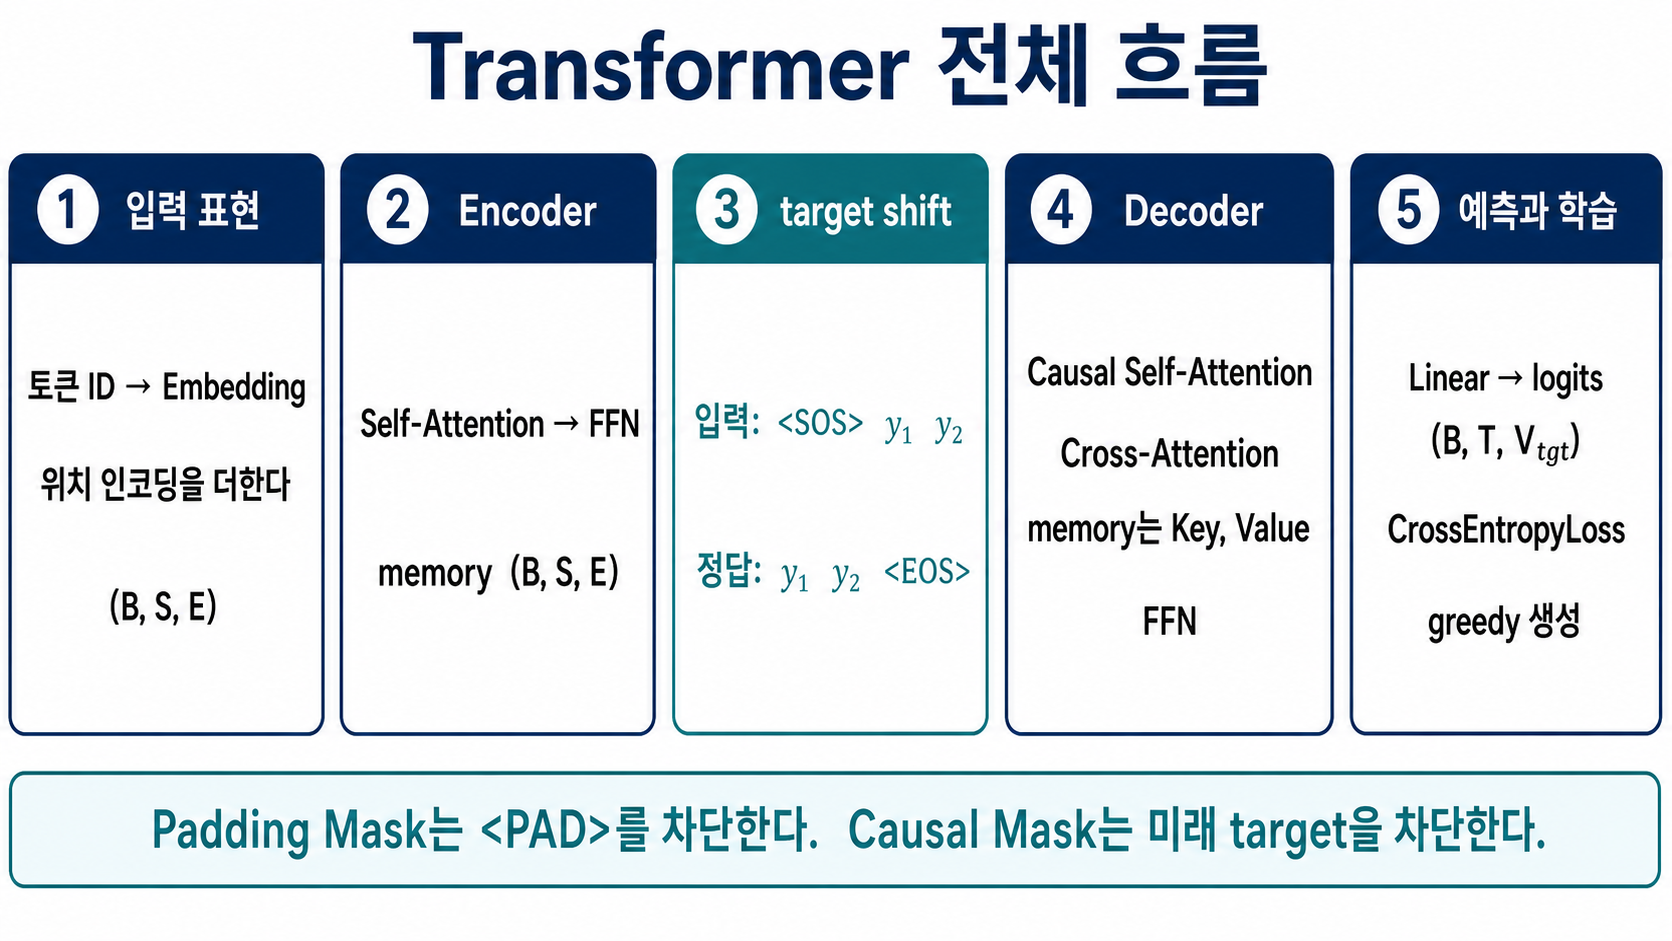
